# Lecture 3: Statistical Modelling and Python
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Implement simple and multiple linear regression
2. Interpret regression coefficients and evaluation metrics
3. Check regression assumptions visually
4. Implement logistic regression for binary classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')
print('Ready.')

Ready.


## 3.1 Simple Linear Regression

**Scenario:** Predict a student's exam score from their study hours.

In [2]:
np.random.seed(42)
n = 200
study_hours = np.random.uniform(1, 10, n)
exam_score  = 40 + 5.5 * study_hours + np.random.normal(0, 8, n)
exam_score  = np.clip(exam_score, 0, 100)

df = pd.DataFrame({'study_hours': study_hours, 'exam_score': exam_score})

X = df[['study_hours']]
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Intercept (β0):   {model.intercept_:.4f}')
print(f'Coefficient (β1): {model.coef_[0]:.4f}')
print(f'MSE:              {mean_squared_error(y_test, y_pred):.4f}')
print(f'RMSE:             {mean_squared_error(y_test, y_pred)**0.5:.4f}')
print(f'R-squared:        {r2_score(y_test, y_pred):.4f}')
print(f'\nInterpretation: Each additional study hour increases exam score by {model.coef_[0]:.2f} points.')

Intercept (β0):   40.1379
Coefficient (β1): 5.5624
MSE:              68.8283
RMSE:             8.2963
R-squared:        0.6935

Interpretation: Each additional study hour increases exam score by 5.56 points.


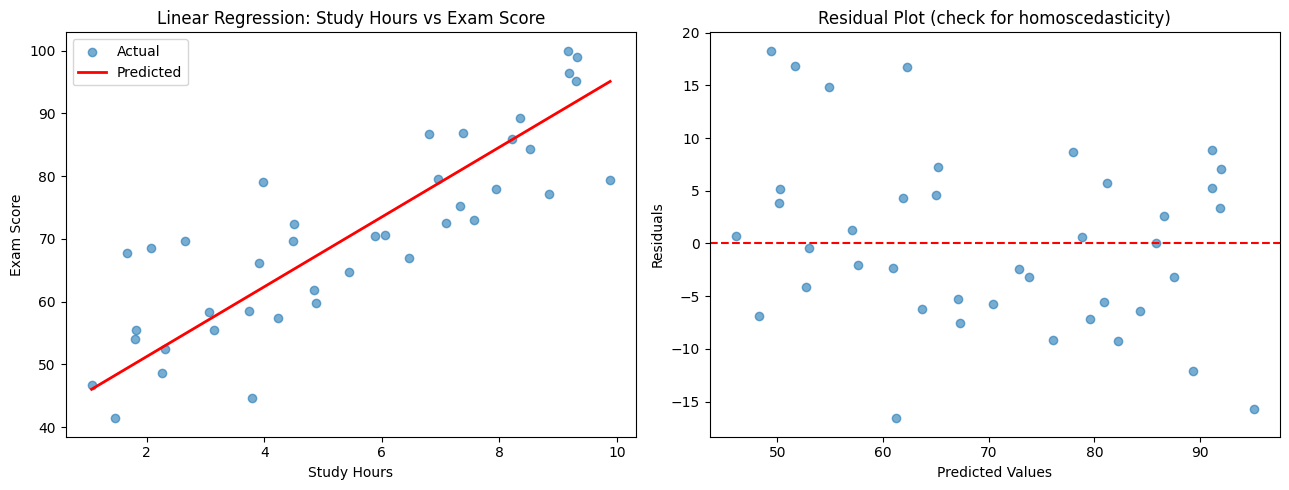

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Regression line
axes[0].scatter(X_test, y_test, alpha=0.6, label='Actual')
axes[0].plot(X_test.sort_values('study_hours'),
             model.predict(X_test.sort_values('study_hours')),
             color='red', linewidth=2, label='Predicted')
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Exam Score')
axes[0].set_title('Linear Regression: Study Hours vs Exam Score')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (check for homoscedasticity)')

plt.tight_layout()
plt.show()

## 3.2 Multiple Linear Regression

In [4]:
np.random.seed(42)
n = 300
study    = np.random.uniform(1, 10, n)
attend   = np.random.uniform(50, 100, n)
prev_gpa = np.random.uniform(1.5, 4.0, n)
score    = 10 + 4.0*study + 0.25*attend + 6.0*prev_gpa + np.random.normal(0, 6, n)
score    = np.clip(score, 0, 100)

df2 = pd.DataFrame({'study_hours': study, 'attendance': attend,
                    'prev_gpa': prev_gpa, 'exam_score': score})

X2 = df2[['study_hours', 'attendance', 'prev_gpa']]
y2 = df2['exam_score']

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

mr = LinearRegression()
mr.fit(X2_tr, y2_tr)
y2_pred = mr.predict(X2_te)

for name, coef in zip(X2.columns, mr.coef_):
    print(f'{name:15s}: {coef:.4f}')
print(f'Intercept:       {mr.intercept_:.4f}')
print(f'R-squared:       {r2_score(y2_te, y2_pred):.4f}')

study_hours    : 4.0039
attendance     : 0.2657
prev_gpa       : 6.7078
Intercept:       7.8229
R-squared:       0.7222


## 3.3 Logistic Regression

**Scenario:** Predict whether a student will pass (score >= 50) based on study hours and attendance.

In [5]:
df3 = df2.copy()
df3['passed'] = (df3['exam_score'] >= 50).astype(int)
print(f'Pass rate: {df3.passed.mean()*100:.1f}%')

X3 = df3[['study_hours', 'attendance', 'prev_gpa']]
y3 = df3['passed']

X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3, test_size=0.2,
                                               random_state=42, stratify=y3)
scaler = StandardScaler()
X3_tr_sc = scaler.fit_transform(X3_tr)
X3_te_sc = scaler.transform(X3_te)

lr = LogisticRegression(random_state=42)
lr.fit(X3_tr_sc, y3_tr)
y3_pred = lr.predict(X3_te_sc)

print('\n=== Classification Report ===')
print(classification_report(y3_te, y3_pred, target_names=['Fail', 'Pass']))

Pass rate: 89.3%

=== Classification Report ===
              precision    recall  f1-score   support

        Fail       0.80      0.67      0.73         6
        Pass       0.96      0.98      0.97        54

    accuracy                           0.95        60
   macro avg       0.88      0.82      0.85        60
weighted avg       0.95      0.95      0.95        60



### Exercise

Using the student performance DataFrame `df2`:

1. Train a Ridge regression model (alpha=1.0) on the same features.
2. Train a Lasso regression model (alpha=0.5).
3. Compare the R-squared of LinearRegression, Ridge, and Lasso on the test set.
4. Print the coefficients of each model. Which features does Lasso shrink most?

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score
import pandas as pd

# Define features (X) and target (y)
# Replace 'final_grade' with your actual target column if different
X = df2.drop('exam_score', axis=1)
y = df2['exam_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize models
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.5)

# Train models
lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

# R-squared scores
lr_r2 = r2_score(y_test, lr_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("R-squared Scores:")
print(f"Linear Regression: {lr_r2:.4f}")
print(f"Ridge Regression : {ridge_r2:.4f}")
print(f"Lasso Regression : {lasso_r2:.4f}")

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'LinearRegression': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

print("\nModel Coefficients:")
print(coef_df)

# Features most shrunk by Lasso
coef_df['Abs_Lasso'] = abs(coef_df['Lasso'])
most_shrunk = coef_df.sort_values('Abs_Lasso')

print("\nFeatures most shrunk by Lasso:")
print(most_shrunk[['Feature', 'Lasso']].head())

R-squared Scores:
Linear Regression: 0.7222
Ridge Regression : 0.7225
Lasso Regression : 0.7252

Model Coefficients:
       Feature  LinearRegression     Ridge     Lasso
0  study_hours          4.003925  4.000985  3.921207
1   attendance          0.265662  0.265852  0.266446
2     prev_gpa          6.707836  6.653851  5.734361

Features most shrunk by Lasso:
       Feature     Lasso
1   attendance  0.266446
0  study_hours  3.921207
2     prev_gpa  5.734361


---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*